In [1]:
!pip install pandas
!pip install numpy

^C



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('setlistfm_tours.csv')

In [4]:
import pandas as pd

def merge_same_day_events(df):
    # Columns that define a unique event location and time
    group_cols = ['eventDate', 'venue']
    
    # Define how to handle all other columns when merging
    aggregations = {
        'artist': lambda x: ' + '.join(x.dropna().astype(str).unique()),
        'tour': lambda x: ' & '.join(x.dropna().astype(str).unique()), # Combine tour names if different
        'date_iso': 'first',
        'city': 'first',
        'state': 'first',
        'stateCode': 'first',
        'country': 'first',
        'countryCode': 'first',
        'latitude': 'first',
        'longitude': 'first',
        'num_songs': 'sum', # Add total songs together
        'setlist_url': lambda x: ' | '.join(x.dropna().astype(str)),
        'setlist_id': lambda x: ' | '.join(x.dropna().astype(str))
    }
    
    # Filter aggregation dictionary to only include columns actually in the DataFrame
    aggregations = {k: v for k, v in aggregations.items() if k in df.columns}
    
    # Group by date and venue, keeping rows where venue might be NaN
    merged_df = df.groupby(group_cols, dropna=False, as_index=False).agg(aggregations)
    
    return merged_df

def travelling_routes(df, date_col, city_col, date_format='%Y-%m-%d'):
    df[date_col] = pd.to_datetime(df[date_col], format=date_format)
    
    df = df.sort_values(by=['tour', date_col]).reset_index(drop=True)
    
    df['previous_city'] = df.groupby('tour')[city_col].shift(1).fillna('First Show')
    df['next_city'] = df.groupby('tour')[city_col].shift(-1).fillna('Final Show')
    
    df.loc[df['tour'].isna(), ['previous_city', 'next_city']] = None
    
    return df

# 1. Merge the co-headliners/festival acts first
merged_events_df = merge_same_day_events(df)

# 2. Calculate the routes on the newly merged data
with_cities_df = travelling_routes(merged_events_df, 'eventDate', 'city', '%d-%m-%Y')

# 3. Export
with_cities_df.to_csv('with_cities_setlistfm_combined_artists_09092026.csv', index=False)

KeyboardInterrupt: 

In [21]:
len(df['venue'].unique().tolist())

47346

In [50]:
def make_stadiums_df(df):
    venues_df = (
        df[['venue', 'city', 'state', 'country', 'latitude', 'longitude']]
        .drop_duplicates(subset='venue')
        .copy()
    )

    venues_df['continent'] = None
    venues_df['outside-inside'] = None

    return venues_df

venues_df = make_stadiums_df(df)
venues_df.to_csv('venues_df.csv', index=False)

In [7]:
venues_claude = pd.read_csv('venues_df_clauded.csv')
venues_claude.head()

,venue,city,state,country,latitude,longitude,continent,outside-inside
0,Melbourne Cricket Ground,Melbourne,Victoria,Australia,-37.813997,144.963323,Oceania,NaN
1,Sandstone Point Hotel,Moreton Bay,Queensland,Australia,-27.250000,153.250000,Oceania,NaN
2,Whitfords Nodes Park,Perth,Western Australia,Australia,-31.933333,115.833333,Oceania,NaN
3,Lazy River Estate,Dubbo,New South Wales,Australia,-32.250000,148.616667,Oceania,NaN
4,Seafront Oval,Hervey Bay,Queensland,Australia,-25.283300,152.833300,Oceania,NaN


In [5]:
with_cities_df = pd.read_csv('with_cities_setlistfm_combined_artists_09092026.csv')
with_cities_df['eventDate'] = (
    pd.to_datetime(with_cities_df['eventDate'], format='%d/%m/%Y', errors='coerce')
      .fillna(pd.to_datetime(with_cities_df['eventDate'], format='%Y-%m-%d', errors='coerce'))
)

C:\Users\jbrooker\AppData\Local\Temp\ipykernel_28620\701731079.py:1: DtypeWarning: Columns (0: tour) have mixed types. Specify dtype option on import or set low_memory=False.
  with_cities_df = pd.read_csv('with_cities_setlistfm_combined_artists_09092026.csv')


In [8]:
with_cities_full = pd.merge(with_cities_df, venues_claude, how='left',
                            on=['venue', 'city', 'state', 'country', 'latitude', 'longitude'])

with_cities_full.head()

,eventDate,venue,artist,tour,date_iso,city,state,stateCode,country,countryCode,latitude,longitude,num_songs,setlist_url,setlist_id,previous_city,next_city,continent,outside-inside
0,1585-03-03,Teatro Olimpico,Various Artists,NaN,1585-03-03,Vicenza,Veneto,20,Italy,IT,45.557294,11.540898,1,https://www.setlist.fm/setlist/various-artists...,53437795,First Show,Montreal,Europe,inside
1,1786-09-07,Jardin musical Vauxhall,Various Artists,NaN,1786-09-07,Montreal,Quebec,QC,Canada,CA,45.508837,-73.587809,10,https://www.setlist.fm/setlist/various-artists...,3b7d557,Vicenza,Montreal,North America,NaN
2,1786-09-26,Jardin musical Vauxhall,Various Artists,NaN,1786-09-26,Montreal,Quebec,QC,Canada,CA,45.508837,-73.587809,0,https://www.setlist.fm/setlist/various-artists...,bb7d526,Montreal,Quebec City,North America,NaN
3,1794-02-24,Salle des Francs-Maçons,Various Artists,NaN,1794-02-24,Quebec City,Quebec,QC,Canada,CA,46.812000,-71.215000,7,https://www.setlist.fm/setlist/various-artists...,2bb7e8de,Montreal,Quebec City,North America,NaN
4,1794-03-10,Salle des Francs-Maçons,Various Artists,NaN,1794-03-10,Quebec City,Quebec,QC,Canada,CA,46.812000,-71.215000,9,https://www.setlist.fm/setlist/various-artists...,13b7e539,Quebec City,Montreal,North America,NaN


C:\Users\jbrooker\AppData\Local\Temp\ipykernel_15984\3089633778.py:1: DtypeWarning: Columns (0: tour) have mixed types. Specify dtype option on import or set low_memory=False.
  with_cities_full = pd.read_csv('with_cities_setlistfm_combined_artists_09092026.csv')


In [9]:
with_cities_europe = with_cities_full[with_cities_full['continent'] == 'Europe']
with_cities_europe.head()

,eventDate,venue,artist,tour,date_iso,city,state,stateCode,country,countryCode,latitude,longitude,num_songs,setlist_url,setlist_id,previous_city,next_city,continent,outside-inside
0,1585-03-03,Teatro Olimpico,Various Artists,NaN,1585-03-03,Vicenza,Veneto,20,Italy,IT,45.557294,11.540898,1,https://www.setlist.fm/setlist/various-artists...,53437795,First Show,Montreal,Europe,inside
64,1940-03-25,Salle du Grand Cercle,Various Artists,NaN,25/03/1940,Angers,Pays de la Loire,52,France,FR,47.476000,-0.514000,0,https://www.setlist.fm/setlist/various-artists...,738de29d,Montreal,Montreal,Europe,inside
172,1954-01-25,Théâtre des Champs Elysées,Gilbert Bécaud,NaN,25/01/1954,Paris,Île-de-France,11,France,FR,48.853000,2.349000,3,https://www.setlist.fm/setlist/gilbert-becaud/...,73ebfec1,Blankenberge,Paris,Europe,inside
173,1954-02-05,L'Olympia Bruno Coquatrix,Gilbert Bécaud,NaN,05/02/1954,Paris,Île-de-France,11,France,FR,48.853000,2.349000,0,https://www.setlist.fm/setlist/gilbert-becaud/...,53eb87e5,Paris,Paris,Europe,inside
174,1954-02-06,L'Olympia Bruno Coquatrix,Gilbert Bécaud,NaN,06/02/1954,Paris,Île-de-France,11,France,FR,48.853000,2.349000,0,https://www.setlist.fm/setlist/gilbert-becaud/...,43eb87db,Paris,Paris,Europe,inside


In [10]:


def month_graph(df):
    # 1. Ensure eventDate is in datetime format
    # Adjust 'format' if your dates are formatted specifically (e.g., format='%d-%m-%Y')
    df['eventDate'] = pd.to_datetime(df['eventDate'])


    # --- Option B: Combined Months Across All Years (Jan-Dec Aggregated) ---
    month_order = [
        'January',
        'February',
        'March',
        'April',
        'May',
        'June',
        'July',
        'August',
        'September',
        'October',
        'November',
        'December',
    ]
    monthly_totals = (
        df['eventDate']
        .dt.month_name()
        .value_counts()
        .reindex(month_order)
        .fillna(0)
    )

    plt.figure(figsize=(10, 5))
    monthly_totals.plot(kind='bar', color='teal', edgecolor='black')
    plt.title('Total Shows by Month')
    plt.xlabel('Month')
    plt.ylabel('Number of Shows')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    return monthly_totals

def day_graph(df):
    # --- Option B: Group by Numerical Day of the Year (1 to 365/366) ---
    day_num_totals = (
        df['eventDate']
        .dt.dayofyear.value_counts()
        .reindex(range(1, 367), fill_value=0)
    )

    plt.figure(figsize=(15, 5))
    plt.bar(day_num_totals.index, day_num_totals.values, color='teal', width=1.0)
    plt.title('Total Shows by Day Number (1–366)')
    plt.xlabel('Day of the Year (1 to 366)')
    plt.ylabel('Number of Shows')
    plt.xlim(1, 366)
    plt.tight_layout()
    plt.show()

    return day_num_totals



def _norm(s):
    return str(s).strip().casefold()
 
 
def group_venues_by_country(df, country_name, top_n=10, count_col='eventDate',
                            centroid_threshold=8, aliases=None, plot=True):
    """Top venues in a country by event count, merging true duplicates only.
 
    The coordinates in this dataset are a mix of (a) genuine per-venue points
    and (b) city-centroid placeholders shared by dozens of unrelated venues.
    So we group with a HYBRID key:
 
      * If a coordinate is shared by <= ``centroid_threshold`` distinct venues,
        it is treated as a real location and everything there is merged
        (this correctly fuses renamed venues, e.g. the Assago Forum aliases).
      * If a coordinate is shared by MORE than that (a city centroid) — or the
        coordinate is missing — we fall back to grouping by the venue name +
        city, so 130 different Milan venues don't collapse into one bar.
      * ``aliases`` (optional) forces known same-venues together regardless of
        coordinates, e.g. {'stadio giuseppe meazza': 'san siro',
                           'ippodromo del galoppo di san siro': 'san siro'}.
        Keys are matched case-insensitively against the venue name.
 
    Returns a DataFrame (venue, city, count, latitude, longitude, n_names_merged)
    sorted by count descending, limited to ``top_n``.
    """
    d = df[df['country'].astype(str).str.strip().str.lower()
           == country_name.strip().lower()].copy()
    if d.empty:
        print(f"No data found for country: '{country_name}'")
        return None
 
    aliases = {_norm(k): v for k, v in (aliases or {}).items()}
    d['_name'] = d['venue'].map(_norm)
 
    # how many DISTINCT venue names share each coordinate point
    has_coord = d['latitude'].notna() & d['longitude'].notna()
    per_pt = (d[has_coord].groupby(['latitude', 'longitude'])['_name']
              .transform('nunique'))
    d['_pt_names'] = per_pt            # NaN where coord missing
    reliable_pt = has_coord & (d['_pt_names'] <= centroid_threshold)
 
    def canon_key(r):
        # 1) explicit alias wins
        if r['_name'] in aliases:
            return ('alias', aliases[r['_name']])
        # 2) trust a precise, low-collision coordinate (merges renamed venues)
        if reliable_pt.loc[r.name]:
            return ('coord', r['latitude'], r['longitude'])
        # 3) centroid / missing coord -> identify by name + city
        return ('name', r['_name'], _norm(r['city']))
 
    d['_key'] = d.apply(canon_key, axis=1)
 
    def most_common(s):
        m = s.dropna().mode()
        return m.iloc[0] if not m.empty else (s.iloc[0] if len(s) else None)
 
    cnt = count_col if count_col in d.columns else 'venue'
    grouped = (d.groupby('_key', dropna=False)
               .agg(venue=('venue', most_common),
                    city=('city', most_common),
                    count=(cnt, 'size'),
                    latitude=('latitude', most_common),
                    longitude=('longitude', most_common),
                    n_names_merged=('_name', 'nunique'))
               .reset_index(drop=True)
               .sort_values('count', ascending=False)
               .head(top_n)
               .reset_index(drop=True))
 
    if plot:
        labels = grouped['venue'] + ' (' + grouped['city'].astype(str) + ')'
        plt.figure(figsize=(10, 6))
        plt.barh(labels[::-1], grouped['count'][::-1], color='coral', edgecolor='black')
        plt.title(f'Top {len(grouped)} Venues in {country_name.title()} by Event Count',
                  fontsize=14)
        plt.xlabel('Number of Events', fontsize=12)
        plt.ylabel('Venue', fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.7)
        plt.tight_layout()
        plt.show()
 
    return grouped

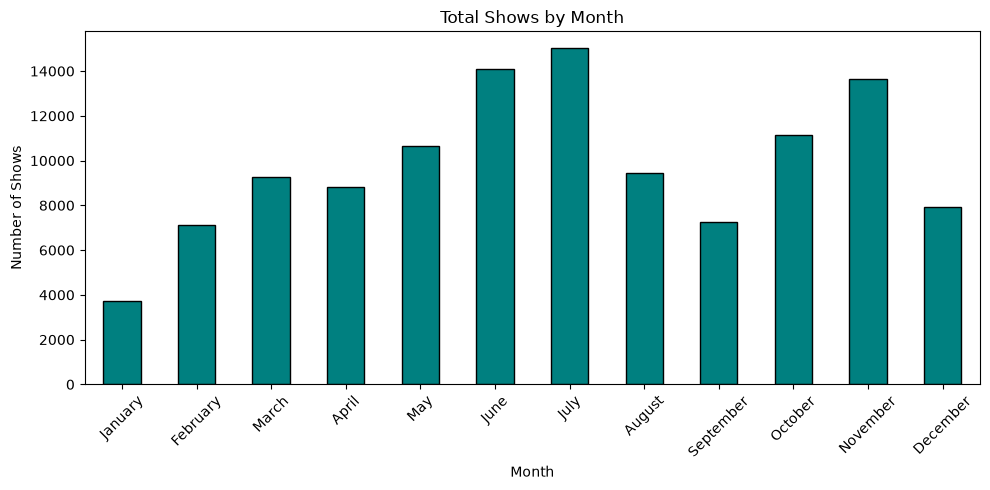

eventDate
January       3746
February      7109
March         9256
April         8807
May          10648
June         14083
July         15026
August        9429
September     7272
October      11128
November     13657
December      7909
Name: count, dtype: int64

In [18]:
month_graph(with_cities_europe)

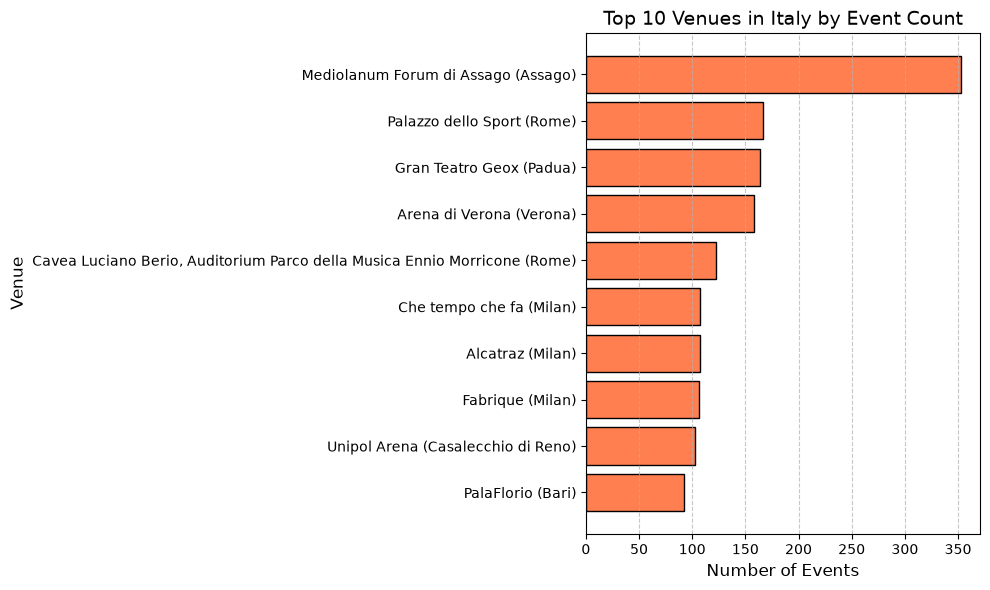

In [56]:
italian_venues = group_venues_by_country(with_cities_europe[with_cities_europe['eventDate'] > '2020-01-01'], 'Italy')
italian_venues.to_csv('italian_venues.csv', index=False)

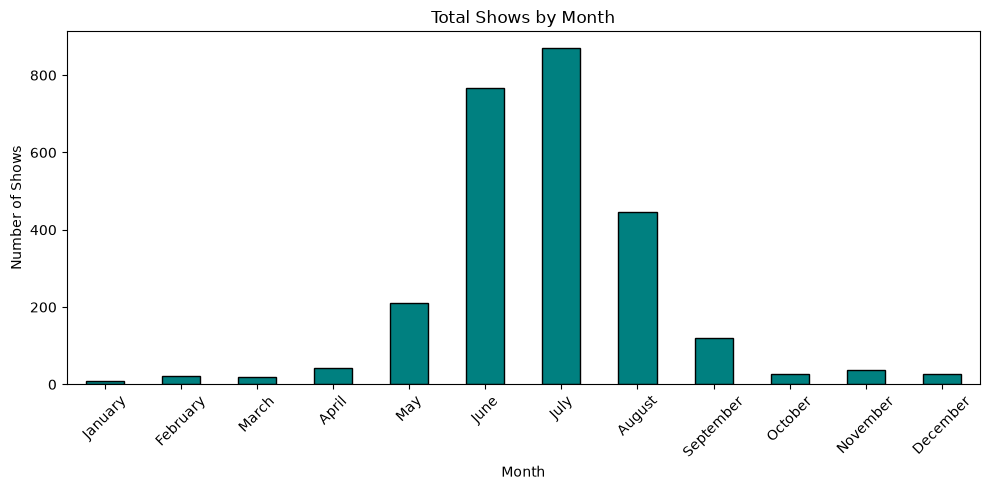

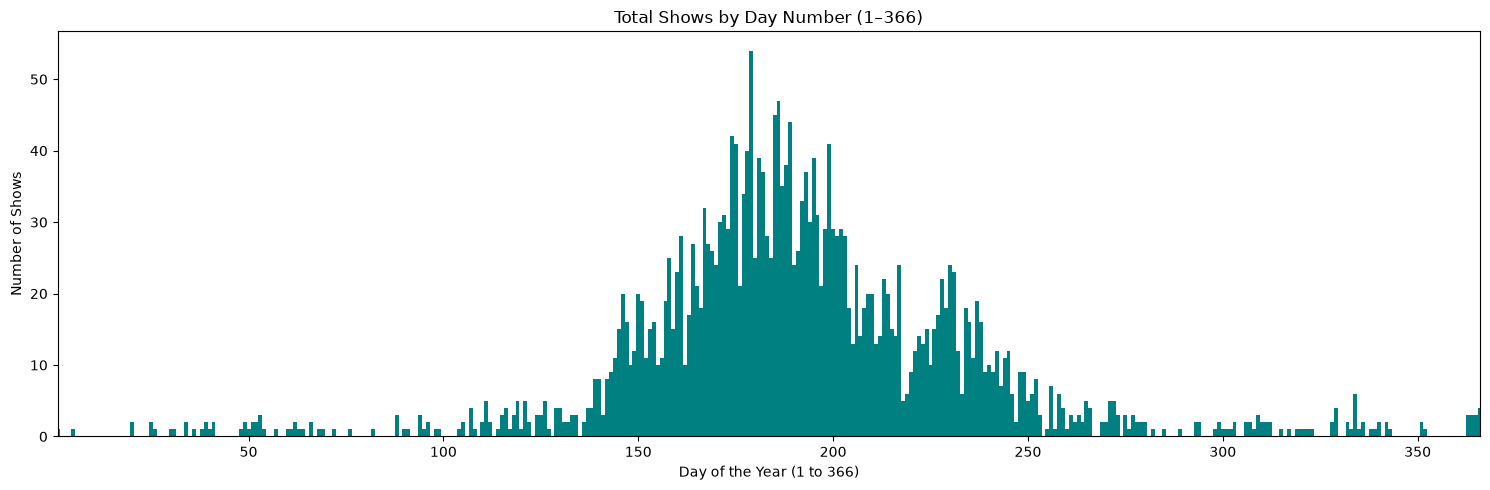

In [15]:
europe_outdoor = with_cities_europe[(with_cities_europe['outside-inside'] == 'outside') & (with_cities_europe['eventDate'] > '2023-01-01')]
# europe_outdoor.to_csv('europe_outdoor.csv', index=False)
outdoor_month_totals = month_graph(europe_outdoor)
outdoor_day_totals = day_graph(europe_outdoor)

In [16]:
outdoor_month_totals.to_excel('datasets/outdoor_month_totals.xlsx')
outdoor_day_totals.to_excel('datasets/outdoor_day_totals.xlsx')

In [47]:
outdoor_month_totals.head(12)

eventDate
January        13
February       23
March          21
April          53
May           443
June         1466
July         1512
August        869
September     284
October        55
November       46
December       35
Name: count, dtype: int64

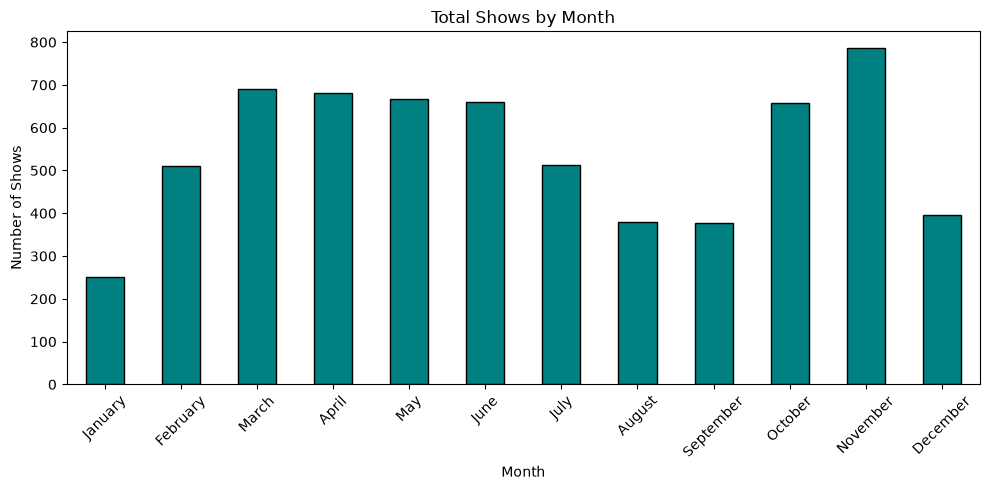

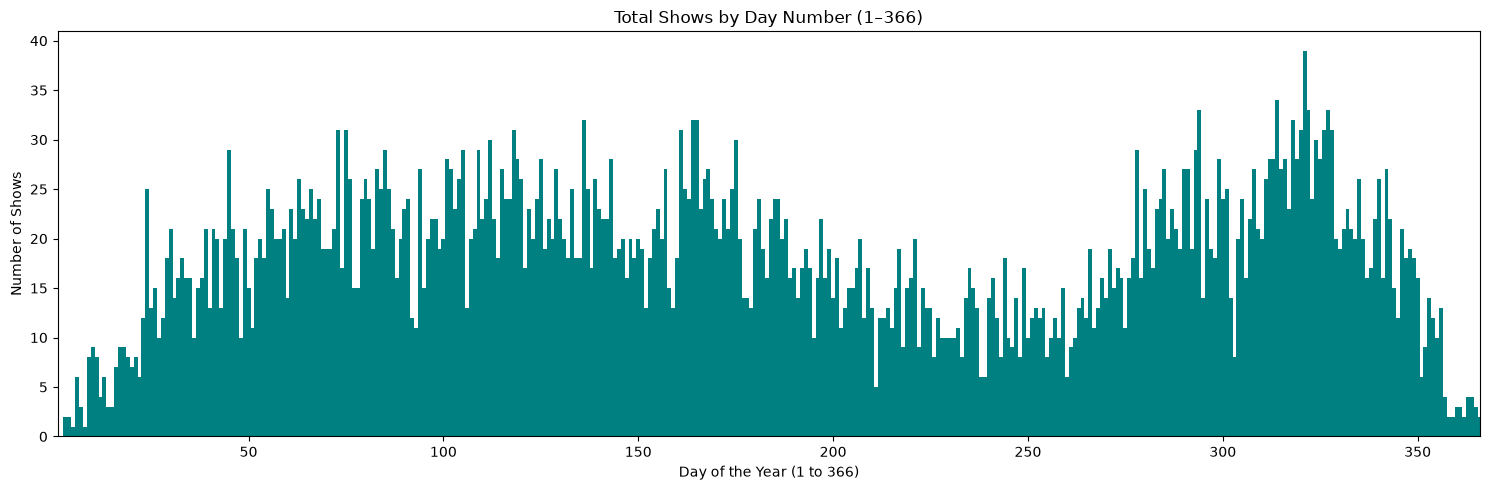

In [17]:
europe_indoor = with_cities_europe[(with_cities_europe['outside-inside'] == 'inside') & (with_cities_europe['eventDate'] > '2023-01-01')]
europe_indoor_month = month_graph(europe_indoor)
europe_indoor_day = day_graph(europe_indoor)
europe_indoor_month.to_excel('datasets/indoor_month_totals.xlsx')
europe_indoor_day.to_excel('datasets/indoor_day_totals.xlsx')

In [29]:
with_cities_europe.columns

Index(['eventDate', 'venue', 'artist', 'tour', 'date_iso', 'city', 'state',
       'stateCode', 'country', 'countryCode', 'latitude', 'longitude',
       'num_songs', 'setlist_url', 'setlist_id', 'previous_city', 'next_city',
       'continent', 'outside-inside'],
      dtype='str')

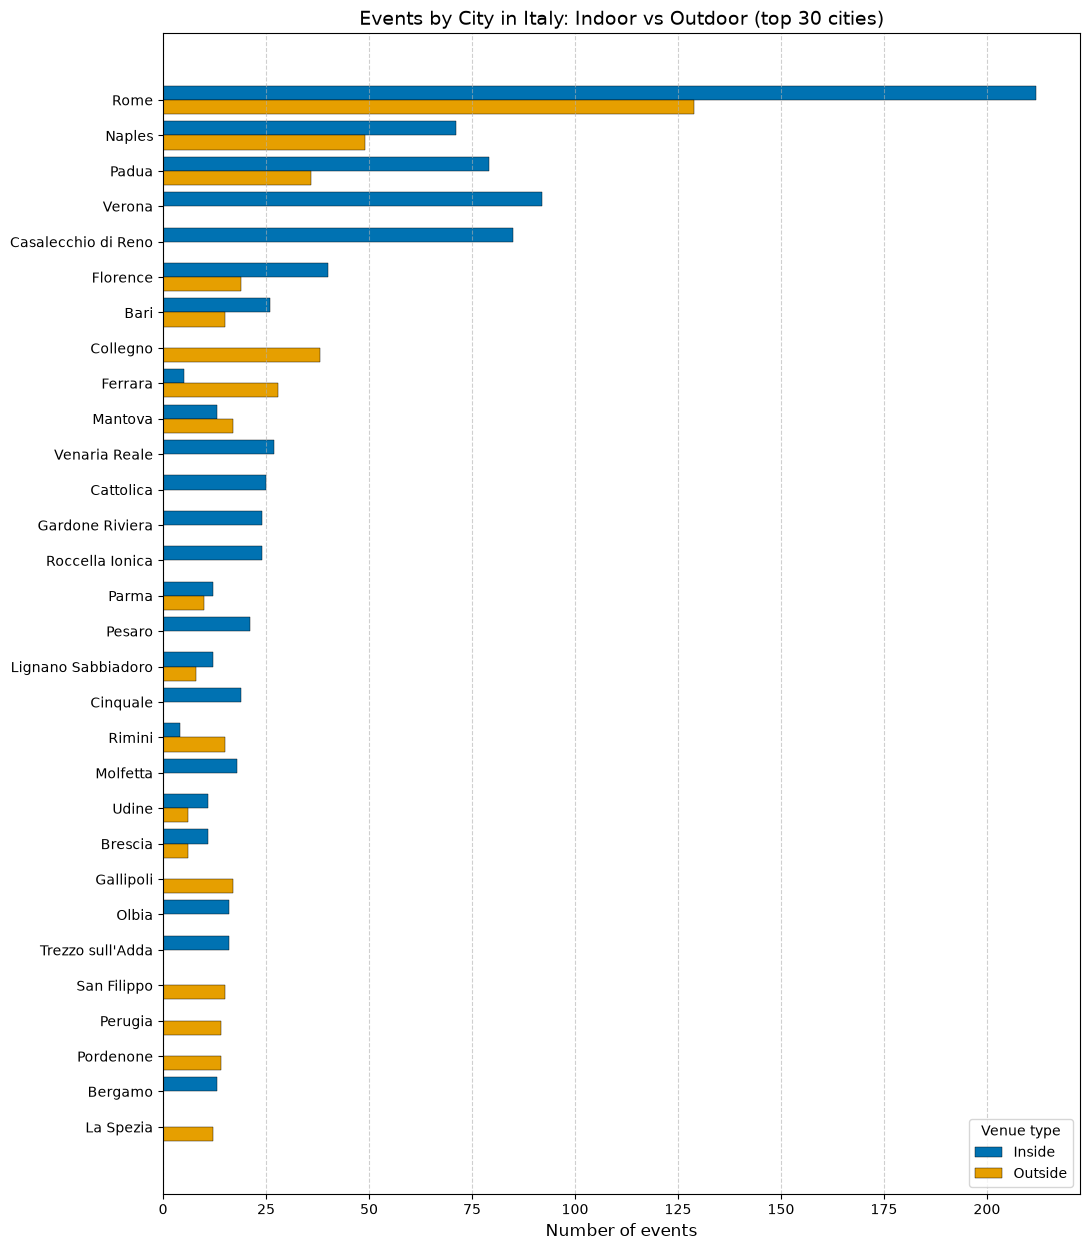

Italy: 1527 classified events across 130 cities; 1240 events had no indoor/outdoor label (excluded).


: 

In [ ]:

# colourblind-safe (Okabe-Ito)
C_INSIDE = '#0072B2'   # blue
C_OUTSIDE = '#E69F00'  # orange
C_UNKNOWN = '#BBBBBB'   # grey


def plot_city_indoor_outdoor(df, country_name, top_n=30, count_col='eventDate',
                             class_col='outside-inside', include_unknown=False,
                             plot=True):
    """Grouped bar chart of events per city, split by indoor vs outdoor venue.

    One row of bars per city (top ``top_n`` cities by classified event count),
    with an 'inside' bar and an 'outside' bar. Rows whose ``class_col`` is
    neither 'inside' nor 'outside' are treated as unknown: excluded by default,
    or shown as a third grey bar if ``include_unknown=True``.

    NOTE: ``class_col`` is only populated for European venues in this dataset,
    so a non-European country will produce an empty chart. If your events
    dataframe has no outside/inside column yet, join it on from venues_df first
    (e.g. df.merge(venues_df[['venue','outside-inside']], on='venue', how='left')).

    ``count_col`` gives the event count (row-count per city/class); if that
    column is absent, each row counts once.

    Returns a DataFrame indexed by city with columns inside / outside
    (/ unknown), sorted by total descending.
    """
    d = df[df['country'].astype(str).str.strip().str.lower()
           == country_name.strip().lower()].copy()
    if d.empty:
        print(f"No data found for country: '{country_name}'")
        return None

    cls = d[class_col].astype(str).str.strip().str.lower()
    d['_cls'] = np.where(cls.isin(['inside', 'outside']), cls, 'unknown')

    if count_col not in d.columns:
        d['_one'] = 1
        count_col = '_one'

    pivot = (d.pivot_table(index='city', columns='_cls', values=count_col,
                           aggfunc='count', fill_value=0))
    for c in ['inside', 'outside', 'unknown']:
        if c not in pivot.columns:
            pivot[c] = 0

    classified = pivot['inside'] + pivot['outside']
    n_unknown = int(pivot['unknown'].sum())
    n_classified = int(classified.sum())
    if n_classified == 0:
        print(f"No indoor/outdoor-classified events for '{country_name}'. "
              f"({n_unknown} events have no {class_col} value — "
              f"is this a European country, and is {class_col} populated?)")
        return pivot

    ranked = pivot.assign(_tot=classified).sort_values('_tot', ascending=False).head(top_n)
    ranked = ranked.drop(columns='_tot')

    if plot:
        cities = ranked.index.tolist()
        y = np.arange(len(cities))
        series = [('inside', C_INSIDE), ('outside', C_OUTSIDE)]
        if include_unknown:
            series.append(('unknown', C_UNKNOWN))
        n = len(series)
        h = 0.8 / n
        plt.figure(figsize=(11, max(6, 0.42 * len(cities))))
        for i, (name, colour) in enumerate(series):
            offset = (i - (n - 1) / 2) * h
            plt.barh(y + offset, ranked[name].values, height=h,
                     color=colour, edgecolor='black', linewidth=0.3,
                     label=name.capitalize())
        plt.yticks(y, cities)
        plt.gca().invert_yaxis()  # biggest city at top
        plt.xlabel('Number of events', fontsize=12)
        plt.title(f'Events by City in {country_name.title()}: Indoor vs Outdoor '
                  f'(top {len(cities)} cities)', fontsize=14)
        plt.legend(title='Venue type')
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    cols = ['inside', 'outside'] + (['unknown'] if include_unknown else [])
    out = ranked[cols].copy()
    out['total'] = out[['inside', 'outside']].sum(axis=1)

    print(f"{country_name.title()}: {n_classified} classified events across "
          f"{len(pivot)} cities; {n_unknown} events had no indoor/outdoor label "
          f"(excluded{' -> shown as grey' if include_unknown else ''}).")
    return out.sort_values('total', ascending=False)


italy_df =plot_city_indoor_outdoor(with_cities_europe[with_cities_europe['eventDate'] > '01-01-2023'], 'Italy')
italy_df.to_excel('datasets/italydf.xlsx')

In [ ]:
italian_df = with_cities_df[(with_cities_df['country'] == 'Italy') & (with_cities_df['eventDate'] > '2023-01-01')]
italian_df.head()

,eventDate,venue,artist,tour,date_iso,city,state,stateCode,country,countryCode,latitude,longitude,num_songs,setlist_url,setlist_id,previous_city,next_city
158469,2020-01-02,"Sala Sinopoli, Auditorium Parco della Musica",Nicola Piovani,,2020-01-02,Rome,Lazio,07,Italy,IT,41.900000,12.483000,11,https://www.setlist.fm/setlist/nicola-piovani/...,5b9b33c8,Byron Bay,Punta del Este
158484,2020-01-05,Auditorium Conciliazione,Giovanni Allevi,,2020-01-05,Rome,Lazio,07,Italy,IT,41.900000,12.483000,13,https://www.setlist.fm/setlist/giovanni-allevi...,639b2e67,Cuiabá,Boston
158492,2020-01-06,Altromondo Studios,M¥SS KETA,,2020-01-06,Rimini,Emilia-Romagna,05,Italy,IT,44.063333,12.580833,0,https://www.setlist.fm/setlist/mss-keta/2020/a...,7b5ec240,Heist-op-den-Berg,New York
158513,2020-01-10,Casa degli artisti,Brunori Sas,,2020-01-10,Milan,Lombardy,09,Italy,IT,45.464269,9.189506,2,https://www.setlist.fm/setlist/brunori-sas/202...,5b9b0b20,Preston,Seoul
158516,2020-01-10,Reward Music Place,Marracash,,2020-01-10,Cologno Monzese,Lombardy,09,Italy,IT,45.530042,9.277954,17,https://www.setlist.fm/setlist/marracash/2020/...,13980979,Dusseldorf,Coldstream


In [23]:
italian_df['state'].unique()

<ArrowStringArray>
[             'Lombardy',              'Piedmont',               'Tuscany',
                 'Lazio',              'Campania',                'Apulia',
        'Emilia-Romagna',                'Veneto',               'Liguria',
                'Umbria',                'Friuli',               'Abruzzo',
                'Sicily',   'Trentino-Alto Adige',           'The Marches',
              'Sardinia',            'Basilicate',              'Calabria',
          'Aosta Valley',                'Latium', 'Friuli Venezia Giulia',
                'Molise',                     nan]
Length: 23, dtype: str

In [59]:
southern_states = ['Campania', 'Sicily', 'Calabria', 'Apulia', 'Basilicate', 'Molise']
southern_italy_df = italian_df[italian_df['state'].isin(southern_states)]
southern_italy_df.head()

,eventDate,venue,artist,tour,date_iso,city,state,stateCode,country,countryCode,latitude,longitude,num_songs,setlist_url,setlist_id,previous_city,next_city
158598,2020-01-18,Demodé Club,Clementino,,2020-01-18,Modugno,Apulia,13,Italy,IT,41.097433,16.777983,14,https://www.setlist.fm/setlist/clementino/2020...,1b9b5174,Rüsselsheim,Thermal
158619,2020-01-19,I Candelai,Brunori Sas,,2020-01-19,Palermo,Sicily,15,Italy,IT,38.115820,13.359761,3,https://www.setlist.fm/setlist/brunori-sas/202...,6b9b525e,Invermay,Chicago
158964,2020-02-07,PalaFlorio,Charlotte,,2020-02-07,Bari,Apulia,13,Italy,IT,41.117734,16.851185,0,https://www.setlist.fm/setlist/charlotte/2020/...,1b982d1c,Sydney,Sanremo
159149,2020-02-15,Auditorium Rai di Napoli,Noemi + Patty Pravo + Fabrizio Moro + Ermal Me...,,2020-02-15,Naples,Campania,04,Italy,IT,40.833333,14.250000,4,https://www.setlist.fm/setlist/noemi/2020/audi...,13987d51 | 13987d5d | 3987d5f | b987d6e | b987...,Milan,Guarulhos
159270,2020-02-21,Casa delle Arti,Management del dolore post‐operatorio,,2020-02-21,Conversano,Apulia,13,Italy,IT,40.966233,17.114792,0,https://www.setlist.fm/setlist/management-del-...,3bb5ecb0,Boston,Taranto


In [60]:
southern_italy_df.to_excel("southern_italy_since_increased_since_2020_09092026.xlsx", index=False)

c:\Users\jbrooker\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xlsxwriter\worksheet.py:1303: UserWarning: Ignoring URL 'https://www.setlist.fm/setlist/skunk-anansie/2025/piazza-del-plebiscito-naples-italy-734746e9.html | https://www.setlist.fm/setlist/annalisa/2025/piazza-del-plebiscito-naples-italy-347417b.html | https://www.setlist.fm/setlist/benji-and-fede/2025/piazza-del-plebiscito-naples-italy-734746ad.html | https://www.setlist.fm/setlist/rose-villain/2025/piazza-del-plebiscito-naples-italy-73474689.html | https://www.setlist.fm/setlist/olly/2025/piazza-del-plebiscito-naples-italy-73474655.html | https://www.setlist.fm/setlist/sophie-and-the-giants/2025/piazza-del-plebiscito-naples-italy-73474629.html | https://www.setlist.fm/setlist/clara/2025/piazza-del-plebiscito-naples-italy-6b4746a6.html | https://www.setlist.fm/setlist/tropico/2025/piazza-del-plebiscito-naples-italy-6b474672.html | https://www.setlist.fm/setlist/sal-da-vinci/2025/piazza-del-plebiscito-naples-it